# H&M Recommendations - Part 3: LightGBM Reranker

Two-stage pipeline: rule-based + ALS retrieval → LightGBM LambdaRank reranker.

**36 features** covering user history, item popularity, trends, co-occurrence,
price, category/segment match, and ALS collaborative filtering scores.

**Evaluation setup:**
- Candidates: rule-based (300) + ALS (50) → ~320 unique per user
- Labels: test-week purchases (Sep 16-22)
- Boundary artifact users removed (>50% repurchase overlap with last train week)
- 80/20 user split: Optuna tunes on 20% val users, final model trained on all users
- **MAP@12 = 0.0616 · NDCG@12 = 0.0859**

## 1. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

BASE = '/content/drive/MyDrive/HM Fashion'

train     = pd.read_parquet(f'{BASE}/processed/train.parquet')
articles  = pd.read_csv(f'{BASE}/processed/articles.csv', dtype={'article_id': str})
customers = pd.read_csv(f'{BASE}/processed/customers.csv')

rule_candidates = pd.read_parquet(f'{BASE}/candidates/als_rule_candidates.parquet')
ground_truth    = pd.read_parquet(f'{BASE}/candidates/ground_truth.parquet')
cf_features     = pd.read_parquet(f'{BASE}/candidates/cf_features.parquet')
co_occ          = pd.read_parquet(f'{BASE}/processed/co_occurrence.parquet')

print(f'Train          : {len(train):,}')
print(f'Rule candidates: {len(rule_candidates):,} users')
print(f'CF features    : {len(cf_features):,} rows')

Train          : 31,548,013
Rule candidates: 68,984 users
CF features    : 21,719,837 rows


Remove users where more than 50% of their test-week purchases are items
they also bought in the last week of train - these are boundary artifact
users whose labels are contaminated by repeated transactions rather than
genuine new preferences.

In [ ]:
one_week_ago    = pd.to_datetime(train['t_dat'].max()) - pd.Timedelta(weeks=1)
last_week       = train[train['t_dat'] >= one_week_ago]
user_last_items = last_week.groupby('customer_id')['article_id'].apply(set).to_dict()

high_rep_test = set()
for uid, test_items_raw in zip(ground_truth['customer_id'], ground_truth['purchased']):
    if isinstance(test_items_raw, set):
        test_items = test_items_raw
    elif isinstance(test_items_raw, (list, np.ndarray)):
        test_items = set(test_items_raw)
    else:
        test_items = set(str(test_items_raw).strip('{}').replace("'", "").split(', '))

    last_items = user_last_items.get(uid, set())
    if len(test_items) == 0: continue
    if len(last_items & test_items) / len(test_items) > 0.5:
        high_rep_test.add(uid)

print(f'Boundary users removed: {len(high_rep_test):,}')

Boundary users removed: 8,264


## 2. Explode Candidate Pool + Labels + 80/20 Split

In [ ]:
# explode rule candidates
pool = rule_candidates.explode('article_id').reset_index(drop=True)
pool['article_id'] = pool['article_id'].astype(str)

# labels: 1 if candidate was actually purchased in test week
gt_dict = dict(zip(ground_truth['customer_id'], ground_truth['purchased']))
pool['label'] = pool.apply(
    lambda row: 1 if row['article_id'] in gt_dict.get(row['customer_id'], set()) else 0,
    axis=1)

# 80/20 user split (held-out users for MAP@12 evaluation)
all_users = pool['customer_id'].unique()
np.random.seed(42)
train_users = set(np.random.choice(all_users, size=int(len(all_users)*0.8), replace=False))
val_users   = set(all_users) - train_users

print(f'Total candidate pairs : {len(pool):,}')
print(f'Positive rate         : {pool["label"].mean():.4f}')
print(f'Train users           : {len(train_users):,}')
print(f'Val users             : {len(val_users):,}')

Total candidate pairs : 21,719,837
Positive rate         : 0.0028
Train users           : 55,187
Val users             : 13,797


## 3. Feature Engineering (BASE_FULL + ALS CF)

Computes every feature in BASE_FULL once. BASE_TOP10 is a subset, picked later by column name.

### 3.1 User / Item Aggregates + `price_ratio`

In [ ]:
split_date = pd.to_datetime(train['t_dat'].max())

# ── user-level aggregates ────────────────────────────────────────────
purchase_counts = train.groupby('customer_id').size().rename('purchase_count')
user_avg_price  = train.groupby('customer_id')['price'].mean().rename('user_avg_price')

user_features = pd.concat([purchase_counts, user_avg_price], axis=1).reset_index()

# ── item-level aggregates (incl. item_category = product_group_name) ─
item_popularity  = train.groupby('article_id').size().rename('item_popularity')
item_first_sale  = train.groupby('article_id')['t_dat'].min()
item_days_active = (split_date - item_first_sale).dt.days.rename('item_days_active')
item_avg_price   = train.groupby('article_id')['price'].mean().rename('item_price')

item_features = pd.concat([item_popularity, item_days_active, item_avg_price], axis=1).reset_index()
item_features = item_features.merge(
    articles[['article_id', 'product_group_name']].rename(
        columns={'product_group_name': 'item_category'}),
    on='article_id', how='left')

# ── merge into pool ──────────────────────────────────────────────────
pool_feat = pool.merge(user_features, on='customer_id', how='left')
pool_feat = pool_feat.merge(item_features, on='article_id', how='left')
pool_feat['price_ratio'] = pool_feat['item_price'] / (pool_feat['user_avg_price'] + 1e-6)

print(f'pool_feat shape after user/item feats: {pool_feat.shape}')

pool_feat shape after user/item feats: (21719837, 10)


### 3.2 User-Item Interactions

In [ ]:
# days since user last bought this specific item
last_purchase_of_item = (train.groupby(['customer_id', 'article_id'])['t_dat']
                              .max().reset_index()
                              .rename(columns={'t_dat': 'last_item_purchase_date'}))
pool_feat = pool_feat.merge(last_purchase_of_item, on=['customer_id', 'article_id'], how='left')
pool_feat['days_since_last_item_purchase'] = (
    (split_date - pool_feat['last_item_purchase_date']).dt.days.fillna(9999))

# how many times user bought this specific item
n_times_purchased = (train.groupby(['customer_id', 'article_id'])
                          .size().reset_index(name='n_times_purchased'))
pool_feat = pool_feat.merge(n_times_purchased, on=['customer_id', 'article_id'], how='left')
pool_feat['n_times_purchased'] = pool_feat['n_times_purchased'].fillna(0)

print(f'pool_feat shape: {pool_feat.shape}')

pool_feat shape: (21719837, 13)


### 3.3 Item Momentum (1w / 2w / 4w) + Trends

In [ ]:
one_week_ago   = split_date - pd.Timedelta(weeks=1)
two_weeks_ago  = split_date - pd.Timedelta(weeks=2)
four_weeks_ago = split_date - pd.Timedelta(weeks=4)

item_purchases_1w = (train[train['t_dat'] >= one_week_ago]
                     .groupby('article_id').size().rename('item_purchases_last_week'))
item_purchases_2w = (train[train['t_dat'] >= two_weeks_ago]
                     .groupby('article_id').size().rename('item_purchases_last_2weeks'))
item_purchases_4w = (train[train['t_dat'] >= four_weeks_ago]
                     .groupby('article_id').size().rename('item_purchases_last_4weeks'))

for s in [item_purchases_1w, item_purchases_2w, item_purchases_4w]:
    pool_feat = pool_feat.merge(s.reset_index(), on='article_id', how='left')

pool_feat[['item_purchases_last_week',
           'item_purchases_last_2weeks',
           'item_purchases_last_4weeks']] = pool_feat[['item_purchases_last_week',
                                                      'item_purchases_last_2weeks',
                                                      'item_purchases_last_4weeks']].fillna(0)

# derived trend features
pool_feat['item_trend_short'] = (
    pool_feat['item_purchases_last_week'] -
    pool_feat['item_purchases_last_2weeks'] / 2) / \
    (pool_feat['item_purchases_last_2weeks'] / 2 + 1e-6)

pool_feat['item_trend_medium'] = (
    pool_feat['item_purchases_last_2weeks'] / 2 -
    pool_feat['item_purchases_last_4weeks'] / 4) / \
    (pool_feat['item_purchases_last_4weeks'] / 4 + 1e-6)

pool_feat[['item_trend_short', 'item_trend_medium']] = \
    pool_feat[['item_trend_short', 'item_trend_medium']].fillna(0)

print(f'pool_feat shape: {pool_feat.shape}')

pool_feat shape: (21719837, 18)


### 3.4 Co-occurrence Count

In [ ]:
co_occ_dict = {(r['article_id_a'], r['article_id_b']): r['co_count']
               for _, r in co_occ.iterrows()}

user_recent_items = (train.sort_values('t_dat', ascending=False)
                          .groupby('customer_id')['article_id']
                          .apply(lambda x: list(x)[:10])
                          .reset_index()
                          .rename(columns={'article_id': 'recent_items'}))

pool_feat = pool_feat.merge(user_recent_items, on='customer_id', how='left')
pool_feat['recent_items'] = pool_feat['recent_items'].apply(
    lambda x: x if isinstance(x, list) else [])

pool_feat['co_occurrence_count'] = pool_feat.apply(
    lambda row: max([co_occ_dict.get((r, row['article_id']), 0)
                     for r in row['recent_items']] or [0]), axis=1)
pool_feat.drop(columns=['recent_items'], inplace=True)

print(f'pool_feat shape: {pool_feat.shape}')

pool_feat shape: (21719837, 19)


### 3.5 Product-Code Features (`p_sale`, `p_*_sale`, `p_repurchase_ratio`, derived ratios)

In [ ]:
# merge product_code into pool_feat (drop stale copy if re-running)
if 'product_code' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['product_code'])
pool_feat = pool_feat.merge(
    articles[['article_id', 'product_code']], on='article_id', how='left')

train_with_pcode = train.merge(
    articles[['article_id', 'product_code']], on='article_id', how='left')

p_sale = (train_with_pcode[train_with_pcode['t_dat'] >= one_week_ago]
          .groupby('product_code').size().rename('p_sale'))
p_2w_sale = (train_with_pcode[train_with_pcode['t_dat'] >= two_weeks_ago]
             .groupby('product_code').size().rename('p_2w_sale'))
p_4w_sale = (train_with_pcode[train_with_pcode['t_dat'] >= four_weeks_ago]
             .groupby('product_code').size().rename('p_4w_sale'))
p_full_sale = (train_with_pcode.groupby('product_code').size().rename('p_full_sale'))

p_buyers   = train_with_pcode.groupby('product_code')['customer_id'].nunique()
p_rebuyers = (train_with_pcode.groupby(['product_code', 'customer_id']).size()
              .reset_index(name='cnt').query('cnt > 1')
              .groupby('product_code')['customer_id'].nunique())
p_repurchase_ratio = (p_rebuyers / p_buyers).fillna(0).rename('p_repurchase_ratio')

# drop stale columns, then merge
for col in ['p_sale', 'p_2w_sale', 'p_4w_sale', 'p_full_sale', 'p_repurchase_ratio']:
    if col in pool_feat.columns:
        pool_feat = pool_feat.drop(columns=[col])
for feat in [p_sale, p_2w_sale, p_4w_sale, p_full_sale, p_repurchase_ratio]:
    pool_feat = pool_feat.merge(feat.reset_index(), on='product_code', how='left')

pool_feat[['p_sale', 'p_2w_sale', 'p_4w_sale', 'p_full_sale', 'p_repurchase_ratio']] = \
    pool_feat[['p_sale', 'p_2w_sale', 'p_4w_sale', 'p_full_sale', 'p_repurchase_ratio']].fillna(0)

# derived features
pool_feat['p_sale_trend']        = (pool_feat['p_sale'] - pool_feat['p_2w_sale'] / 2) / \
                                    (pool_feat['p_2w_sale'] / 2 + 1e-6)
pool_feat['p_w_full_sale_ratio'] = pool_feat['p_sale'] / (pool_feat['p_full_sale'] + 1e-6)
pool_feat['i_sale_ratio']        = pool_feat['item_purchases_last_week'] / \
                                    (pool_feat['p_sale'] + 1e-6)

print(f'pool_feat shape: {pool_feat.shape}')

pool_feat shape: (21719837, 28)


### 3.6 User Age

In [ ]:
user_age = customers.set_index('customer_id')['age'].fillna(
    customers['age'].median()).to_dict()
pool_feat['user_age'] = pool_feat['customer_id'].map(user_age).fillna(
    customers['age'].median())

print(f'user_age mean: {pool_feat["user_age"].mean():.1f}')

user_age mean: 35.8


### 3.7 Section, Product-Type, Rank, Repurchase-by-Type

In [ ]:
# user's favourite section and product type
train_with_sec = train.merge(
    articles[['article_id', 'section_name', 'product_type_name']],
    on='article_id', how='left')

user_fav_section = (train_with_sec.groupby(['customer_id', 'section_name'])
                                   .size().reset_index(name='cnt')
                                   .sort_values('cnt', ascending=False)
                                   .groupby('customer_id').first()['section_name']
                                   .rename('user_fav_section'))

user_fav_type = (train_with_sec.groupby(['customer_id', 'product_type_name'])
                                .size().reset_index(name='cnt')
                                .sort_values('cnt', ascending=False)
                                .groupby('customer_id').first()['product_type_name']
                                .rename('user_fav_type'))

pool_feat['user_fav_section'] = pool_feat['customer_id'].map(user_fav_section)
pool_feat['user_fav_type']    = pool_feat['customer_id'].map(user_fav_type)

# merge item-level section_name + product_type_name (drop stale first)
for col in ['section_name', 'product_type_name']:
    if col in pool_feat.columns:
        pool_feat = pool_feat.drop(columns=[col])
pool_feat = pool_feat.merge(
    articles[['article_id', 'section_name', 'product_type_name']],
    on='article_id', how='left')

pool_feat['section_match']      = (pool_feat['user_fav_section'] == pool_feat['section_name']).astype(int)
pool_feat['product_type_match'] = (pool_feat['user_fav_type']    == pool_feat['product_type_name']).astype(int)

# item rank in section
section_pop = (train.merge(
    articles[['article_id', 'section_name']], on='article_id', how='left')
    .groupby(['section_name', 'article_id']).size().reset_index(name='cnt'))
section_pop['item_rank_in_section'] = (section_pop.groupby('section_name')['cnt']
                                                    .rank(ascending=False, method='min'))
if 'item_rank_in_section' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['item_rank_in_section'])
pool_feat = pool_feat.merge(
    section_pop[['article_id', 'section_name', 'item_rank_in_section']],
    on=['article_id', 'section_name'], how='left')
pool_feat['item_rank_in_section'] = pool_feat['item_rank_in_section'].fillna(9999)

# item repurchase rate by product type
train_sorted = train.sort_values(['customer_id', 'article_id', 't_dat'])
train_sorted['is_repurchase'] = train_sorted.duplicated(
    subset=['customer_id', 'article_id'], keep='first')
train_with_type = train_sorted.merge(
    articles[['article_id', 'product_type_name']], on='article_id', how='left')
type_repurchase_rate = (train_with_type.groupby('product_type_name')['is_repurchase']
                                        .mean().rename('item_repurchase_rate_by_type'))
pool_feat['item_repurchase_rate_by_type'] = pool_feat['product_type_name'].map(
    type_repurchase_rate).fillna(0)

print(f'pool_feat shape: {pool_feat.shape}')

pool_feat shape: (21719837, 37)


### 3.8 Index-Group, Colour, `bought_*_before` flags

In [ ]:
# ── bought_this_product_type_before ──────────────────────────────────
user_product_types = (train.merge(
    articles[['article_id', 'product_type_name']], on='article_id', how='left')
    .groupby('customer_id')['product_type_name']
    .apply(set).to_dict())

pool_feat['bought_this_product_type_before'] = pool_feat.apply(
    lambda r: 1 if r['product_type_name'] in
    user_product_types.get(r['customer_id'], set()) else 0, axis=1)

# ── bought_this_index_group_before + index_group_match + enc ─────────
if 'index_group_name' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['index_group_name'])
pool_feat = pool_feat.merge(
    articles[['article_id', 'index_group_name']], on='article_id', how='left')

user_index_groups = (train.merge(
    articles[['article_id', 'index_group_name']], on='article_id', how='left')
    .groupby('customer_id')['index_group_name']
    .apply(set).to_dict())

pool_feat['bought_this_index_group_before'] = pool_feat.apply(
    lambda r: 1 if r['index_group_name'] in
    user_index_groups.get(r['customer_id'], set()) else 0, axis=1)

# user's favourite index_group
user_fav_index_group = (train.merge(
    articles[['article_id', 'index_group_name']], on='article_id', how='left')
    .groupby(['customer_id', 'index_group_name']).size()
    .reset_index(name='cnt').sort_values('cnt', ascending=False)
    .groupby('customer_id').first()['index_group_name'].to_dict())

pool_feat['user_fav_index_group'] = pool_feat['customer_id'].map(user_fav_index_group)
pool_feat['index_group_match']    = (
    pool_feat['index_group_name'] == pool_feat['user_fav_index_group']).astype(int)
pool_feat['user_fav_index_group_enc'] = pool_feat['user_fav_index_group']\
                                        .astype('category').cat.codes

# ── item_colour_in_user_history ──────────────────────────────────────
train_with_colour = train.merge(
    articles[['article_id', 'perceived_colour_master_name']],
    on='article_id', how='left')
user_colours_bought = (train_with_colour.groupby('customer_id')['perceived_colour_master_name']
                                         .apply(set).to_dict())

if 'perceived_colour_master_name' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['perceived_colour_master_name'])
pool_feat = pool_feat.merge(
    articles[['article_id', 'perceived_colour_master_name']],
    on='article_id', how='left')

pool_feat['item_colour_in_user_history'] = pool_feat.apply(
    lambda r: 1 if r['perceived_colour_master_name'] in
    user_colours_bought.get(r['customer_id'], set()) else 0, axis=1)

print(f'bought_this_product_type_before mean : {pool_feat["bought_this_product_type_before"].mean():.3f}')
print(f'bought_this_index_group_before mean  : {pool_feat["bought_this_index_group_before"].mean():.3f}')
print(f'index_group_match mean               : {pool_feat["index_group_match"].mean():.3f}')
print(f'item_colour_in_user_history mean     : {pool_feat["item_colour_in_user_history"].mean():.3f}')

bought_this_product_type_before mean : 0.615
bought_this_index_group_before mean  : 0.856
index_group_match mean               : 0.584
item_colour_in_user_history mean     : 0.756


### 3.9 User × Category Count

In [ ]:
user_cat_counts = (train.merge(articles[['article_id', 'product_group_name']],
                               on='article_id', how='left')
                        .groupby(['customer_id', 'product_group_name'])
                        .size().reset_index(name='user_purchase_count_in_category'))

if 'user_purchase_count_in_category' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['user_purchase_count_in_category'])
pool_feat = pool_feat.merge(
    user_cat_counts.rename(columns={'product_group_name': 'item_category'}),
    on=['customer_id', 'item_category'], how='left')
pool_feat['user_purchase_count_in_category'] = \
    pool_feat['user_purchase_count_in_category'].fillna(0)

print(f'user_purchase_count_in_category mean: {pool_feat["user_purchase_count_in_category"].mean():.2f}')

user_purchase_count_in_category mean: 18.46


### 3.10 Basket Size + Per-Type Weekly Average

In [ ]:
train['year_week'] = (pd.to_datetime(train['t_dat']).dt.year.astype(str) + '_' +
                      pd.to_datetime(train['t_dat']).dt.isocalendar().week.astype(str))
train_with_types = train.merge(
    articles[['article_id', 'product_type_name']], on='article_id', how='left')

weekly_counts   = (train_with_types.groupby(['customer_id', 'year_week'])
                                     .size().reset_index(name='cnt'))
user_avg_weekly = weekly_counts.groupby('customer_id')['cnt'].mean()\
                               .rename('avg_items_per_week')
pool_feat['average_items_count_in_same_week'] = pool_feat['customer_id']\
                                                 .map(user_avg_weekly).fillna(0)

# average items of this product type per week
type_weekly = (train_with_types.groupby(['customer_id', 'year_week', 'product_type_name'])
               .size().reset_index(name='cnt'))
avg_type_weekly = (type_weekly.groupby(['customer_id', 'product_type_name'])['cnt']
                               .mean().reset_index(name='avg_type_per_week'))

if 'avg_type_per_week' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['avg_type_per_week'])
pool_feat = pool_feat.merge(avg_type_weekly,
                            on=['customer_id', 'product_type_name'], how='left')
pool_feat['avg_category_type_per_week'] = pool_feat['avg_type_per_week'].fillna(0)
pool_feat = pool_feat.drop(columns=['avg_type_per_week'], errors='ignore')

print(f'average_items_count_in_same_week mean : {pool_feat["average_items_count_in_same_week"].mean():.2f}')
print(f'avg_category_type_per_week mean       : {pool_feat["avg_category_type_per_week"].mean():.2f}')

average_items_count_in_same_week mean : 3.63
avg_category_type_per_week mean       : 1.05


### 3.11 Max Price for Category Type

In [ ]:
user_max_price_by_type = (train.merge(
    articles[['article_id', 'product_type_name']], on='article_id', how='left')
    .groupby(['customer_id', 'product_type_name'])['price'].max()
    .reset_index(name='max_price_for_type'))

if 'max_price_for_type' in pool_feat.columns:
    pool_feat = pool_feat.drop(columns=['max_price_for_type'])
pool_feat = pool_feat.merge(
    user_max_price_by_type, on=['customer_id', 'product_type_name'], how='left')
pool_feat['max_price_for_category_type'] = pool_feat['max_price_for_type'].fillna(0)
pool_feat = pool_feat.drop(columns=['max_price_for_type'], errors='ignore')

print(f'max_price_for_category_type mean: {pool_feat["max_price_for_category_type"].mean():.4f}')

max_price_for_category_type mean: 0.0255


### 3.12 `fav_1month_category_match`

In [ ]:
train_with_pg = train.merge(
    articles[['article_id', 'product_group_name']], on='article_id', how='left')

cutoff_1m = split_date - pd.Timedelta(days=30)
fav_1m = (train_with_pg[pd.to_datetime(train_with_pg['t_dat']) >= cutoff_1m]
          .groupby(['customer_id', 'product_group_name']).size()
          .reset_index(name='cnt').sort_values('cnt', ascending=False)
          .groupby('customer_id').first()['product_group_name'].to_dict())

pool_feat['fav_1month_category']       = pool_feat['customer_id'].map(fav_1m).fillna('unknown')
pool_feat['fav_1month_category_match'] = (
    pool_feat['fav_1month_category'] == pool_feat['item_category']).astype(int)

print(f'fav_1month_category_match mean: {pool_feat["fav_1month_category_match"].mean():.3f}')

fav_1month_category_match mean: 0.193


### 3.13 ALS CF Features (the NEW features we are testing)

In [ ]:
pool_feat = pool_feat.merge(cf_features, on=['customer_id', 'article_id'], how='left')
pool_feat['als_user_score']    = pool_feat['als_user_score'].fillna(0)
pool_feat['als_item_cf_score'] = pool_feat['als_item_cf_score'].fillna(0)

print(f'als_user_score mean    : {pool_feat["als_user_score"].mean():.4f}')
print(f'als_item_cf_score mean : {pool_feat["als_item_cf_score"].mean():.4f}')
print(f'Final pool_feat shape  : {pool_feat.shape}')

als_user_score mean    : 0.0036
als_item_cf_score mean : 0.0807
Final pool_feat shape  : (21719837, 53)


## 4. Feature Columns & Train/Val Split

In [ ]:
BASE_TOP10 = [
    'days_since_last_item_purchase',
    'n_times_purchased',
    'co_occurrence_count',
    'item_purchases_last_2weeks',
    'item_purchases_last_week',
    'price_ratio',
    'purchase_count',
    'item_popularity',
    'item_days_active',
    'p_repurchase_ratio',
]

BASE_FULL = [
    'days_since_last_item_purchase',
    'n_times_purchased',
    'item_purchases_last_2weeks',
    'co_occurrence_count',
    'item_purchases_last_week',
    'price_ratio',
    'purchase_count',
    'item_popularity',
    'item_days_active',
    'p_repurchase_ratio',
    'user_age',
    'item_trend_medium',
    'p_w_full_sale_ratio',
    'item_purchases_last_4weeks',
    'p_sale_trend',
    'item_trend_short',
    'i_sale_ratio',
    'p_sale',
    'item_rank_in_section',
    'p_2w_sale',
    'section_match',
    'item_repurchase_rate_by_type',
    'p_4w_sale',
    'user_purchase_count_in_category',
    'bought_this_product_type_before',
    'product_type_match',
    'user_fav_index_group_enc',
    'bought_this_index_group_before',
    'index_group_match',
    'item_colour_in_user_history',
    'max_price_for_category_type',
    'avg_category_type_per_week',
    'average_items_count_in_same_week',
    'fav_1month_category_match',
    'als_user_score',
    'als_item_cf_score',
]

ALL_COLS = list(dict.fromkeys(BASE_FULL))  # dedup, keep order

# sanity check — every expected column exists
missing = [c for c in ALL_COLS if c not in pool_feat.columns]
assert not missing, f'Missing columns in pool_feat: {missing}'

pool_feat[ALL_COLS] = pool_feat[ALL_COLS].fillna(0)

train_pool_feat = pool_feat[pool_feat['customer_id'].isin(train_users)].copy()
val_pool_feat   = pool_feat[pool_feat['customer_id'].isin(val_users)].copy()

print(f'BASE_TOP10    : {len(BASE_TOP10)} features')
print(f'BASE_FULL     : {len(BASE_FULL)} features')
print(f'Train pool    : {len(train_pool_feat):,}  pos rate: {train_pool_feat["label"].mean():.4f}')
print(f'Val pool      : {len(val_pool_feat):,}  pos rate: {val_pool_feat["label"].mean():.4f}')

BASE_TOP10    : 10 features
BASE_FULL     : 36 features
Train pool    : 17,375,806  pos rate: 0.0028
Val pool      : 4,344,031  pos rate: 0.0028


## 5. Eval Helpers

In [ ]:
def map_at_k(pred_df, ground_truth, k=12):
    merged = pred_df.merge(ground_truth, on='customer_id', how='inner')
    def avg_precision(row):
        top_k     = row['article_id'][:k]
        purchased = row['purchased']
        hits, score = 0, 0.0
        for i, item in enumerate(top_k):
            if item in purchased:
                hits  += 1
                score += hits / (i + 1)
        return score / min(len(purchased), k)
    return merged.apply(avg_precision, axis=1).mean()

def ndcg_at_k(pred_df, ground_truth, k=12):
    merged = pred_df.merge(ground_truth, on='customer_id', how='inner')
    def ndcg(row):
        top_k      = row['article_id'][:k]
        purchased  = row['purchased']
        ideal_hits = min(len(purchased), k)
        ideal_dcg  = sum(1 / np.log2(i+2) for i in range(ideal_hits))
        if ideal_dcg == 0: return 0.0
        dcg = sum(1 / np.log2(i+2) for i, item in enumerate(top_k) if item in purchased)
        return dcg / ideal_dcg
    return merged.apply(ndcg, axis=1).mean()

def pool_to_topk(pool_df, score_col, k=12):
    return (pool_df.sort_values(score_col, ascending=False)
                   .groupby('customer_id')['article_id']
                   .apply(list).reset_index())

val_gt = ground_truth[ground_truth['customer_id'].isin(val_users)]


<!-- Forward selection section - kept for reference, replaced by Optuna below -->

<!-- Forward selection section - kept for reference, replaced by Optuna below -->

## 6. Hyperparameter Tuning (Optuna)

In [ ]:
!pip install optuna -q

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

FEATURE_COLS = BASE_FULL.copy()

X_train = train_pool_feat[FEATURE_COLS].fillna(0).values
y_train = train_pool_feat['label'].values
g_train = train_pool_feat.groupby('customer_id').size().values
X_val   = val_pool_feat[FEATURE_COLS].fillna(0).values

def objective(trial):
    params = {
        'objective':         'lambdarank',
        'metric':            'ndcg',
        'verbose':           -1,
        'n_jobs':            -1,
        'device':            'gpu',
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    model = lgb.LGBMRanker(**params)
    model.fit(X_train, y_train, group=g_train)

    val_copy = val_pool_feat.copy()
    val_copy['score'] = model.predict(X_val)
    preds = pool_to_topk(val_copy, 'score', k=12)
    return map_at_k(preds, val_gt)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest MAP@12 : {study.best_value:.4f}')
print(f'Best params :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 18.6 MB/s eta 0:00:00


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:27


Best MAP@12 : 0.0507
Best params :
  n_estimators: 433
  learning_rate: 0.02118966946679793
  num_leaves: 69
  min_child_samples: 14
  subsample: 0.6897496184983147
  colsample_bytree: 0.8092807740623188
  reg_alpha: 1.5454625658162795
  reg_lambda: 0.000567785600769701


## 7. Train Final Model on All Users

In [ ]:
# retrain on ALL users (train + val) with best Optuna params
best_params = {
    'objective':  'lambdarank',
    'metric':     'ndcg',
    'verbose':    -1,
    'n_jobs':     -1,
    'device':     'gpu',
    **study.best_params
}

X_all = pool_feat[FEATURE_COLS].fillna(0).values
y_all = pool_feat['label'].values
g_all = pool_feat.groupby('customer_id').size().values

lgb_model = lgb.LGBMRanker(**best_params)
lgb_model.fit(X_all, y_all, group=g_all)

print('Model trained on all users with best params')


Model trained on all users with best params


## 8. Evaluate on Val Set

In [ ]:
val_pool_feat['lgb_score'] = lgb_model.predict(
    val_pool_feat[FEATURE_COLS].fillna(0).values)
lgb_preds = pool_to_topk(val_pool_feat, 'lgb_score', k=12)

lgb_map  = map_at_k(lgb_preds,  val_gt)
lgb_ndcg = ndcg_at_k(lgb_preds, val_gt)

print(f'MAP@12  : {lgb_map:.4f}')
print(f'NDCG@12 : {lgb_ndcg:.4f}')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


MAP@12  : 0.0616
NDCG@12 : 0.0859


## 9. Feature Importance

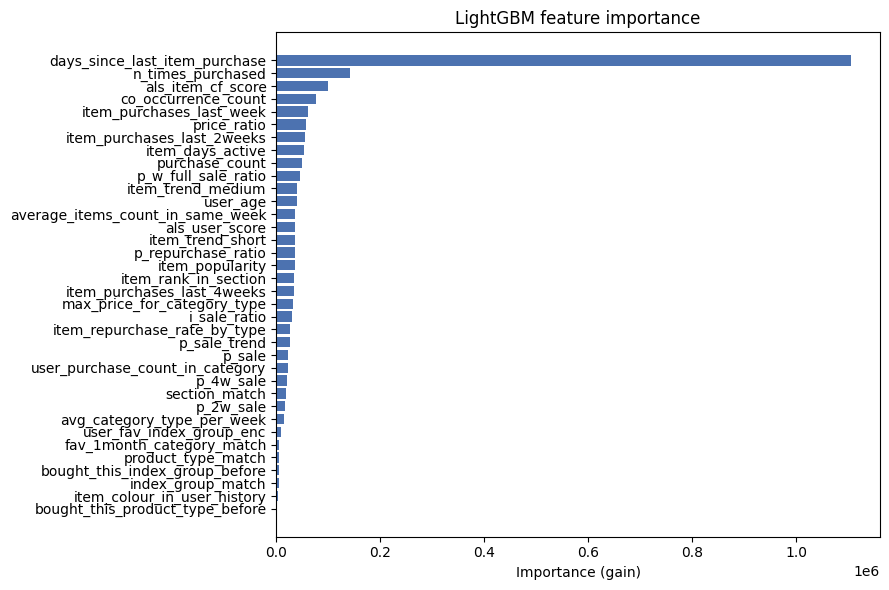

                         feature   importance
   days_since_last_item_purchase 1.106377e+06
               n_times_purchased 1.421645e+05
               als_item_cf_score 9.874525e+04
             co_occurrence_count 7.661275e+04
        item_purchases_last_week 6.041853e+04
                     price_ratio 5.746882e+04
      item_purchases_last_2weeks 5.431844e+04
                item_days_active 5.266168e+04
                  purchase_count 4.961024e+04
             p_w_full_sale_ratio 4.464991e+04
               item_trend_medium 4.019109e+04
                        user_age 3.928726e+04
average_items_count_in_same_week 3.660887e+04
                  als_user_score 3.639184e+04
                item_trend_short 3.567881e+04
              p_repurchase_ratio 3.554683e+04
                 item_popularity 3.549725e+04
            item_rank_in_section 3.376887e+04
      item_purchases_last_4weeks 3.337394e+04
     max_price_for_category_type 3.140868e+04
                    i_sale_ratio 3

In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': lgb_model.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance['feature'][::-1], importance['importance'][::-1], color='#4C72B0')
ax.set_xlabel('Importance (gain)')
ax.set_title('LightGBM feature importance')
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))


## 10. Save Model

In [ ]:
MODEL_PATH = f'{BASE}/candidates/lgb_model.txt'
FEATS_PATH = f'{BASE}/candidates/lgb_model_features.txt'

lgb_model.booster_.save_model(MODEL_PATH)
with open(FEATS_PATH, 'w') as f:
    f.write('\n'.join(FEATURE_COLS))

print(f'Saved model    : {MODEL_PATH}')
print(f'Saved features : {FEATS_PATH}')
print(f'Features       : {len(FEATURE_COLS)}')
print(f'MAP@12         : {lgb_map:.4f}')


Saved model    : /content/drive/MyDrive/HM Fashion/candidates/lgb_model.txt
Saved features : /content/drive/MyDrive/HM Fashion/candidates/lgb_model_features.txt
Features       : 36
MAP@12         : 0.0616


# 11. Comparasion with baselines

In [ ]:
# ── Load saved model ──────────────────────────────────────────────────────────
import lightgbm as lgb

saved_model = lgb.Booster(model_file=f'{BASE}/candidates/lgb_model.txt')

# score all val users
val_pool_feat['lgb_score'] = saved_model.predict(val_pool_feat[FEATURE_COLS].fillna(0))
lgb_preds = pool_to_topk(val_pool_feat, 'lgb_score', k=12)

# ── Baseline 1: global top-12 popularity ─────────────────────────────────────
item_pop       = train.groupby('article_id').size().sort_values(ascending=False)
global_top12   = item_pop.head(12).index.tolist()
global_preds   = pd.DataFrame({
    'customer_id': val_pool_feat['customer_id'].unique(),
    'article_id':  [global_top12] * val_pool_feat['customer_id'].nunique()
})

# ── Baseline 2: candidates ranked by popularity ───────────────────────────────
val_pool_feat['pop_score'] = val_pool_feat['article_id'].map(item_pop).fillna(0)
pop_preds = pool_to_topk(val_pool_feat, 'pop_score', k=12)

# ── Baseline 3: candidates in retrieval order (first 12) ─────────────────────
retrieval_preds = (val_pool_feat
    .groupby('customer_id')['article_id']
    .apply(lambda x: list(x)[:12])
    .reset_index())

# ── Evaluate all ──────────────────────────────────────────────────────────────
results = {
    'Global top-12 popularity':          global_preds,
    'Candidates ranked by popularity':   pop_preds,
    'Candidates in retrieval order':     retrieval_preds,
    'LightGBM reranker (saved model)':   lgb_preds,
}

print(f'{"Model":<40} {"MAP@12":>8} {"NDCG@12":>9}')
print('─' * 60)
for name, preds in results.items():
    m = map_at_k(preds,  val_gt)
    n = ndcg_at_k(preds, val_gt)
    print(f'{name:<40} {m:>8.4f} {n:>9.4f}')

Model                                      MAP@12   NDCG@12
────────────────────────────────────────────────────────────
Global top-12 popularity                   0.0028    0.0052
Candidates ranked by popularity            0.0034    0.0072
Candidates in retrieval order              0.0384    0.0502
LightGBM reranker (saved model)            0.0616    0.0859


### Feature Selection Methodology (Forward Selection - reference only)

Features were selected using forward selection - iteratively adding the feature
that most improves MAP@12 on the validation set. Starting from a base set of
repurchase and popularity features, each candidate feature was evaluated
independently and added only if it improved MAP@12 by at least 0.0005.

The process confirmed the final 36 features (BASE_FULL). This cell is kept
for reference - in the final pipeline forward selection is replaced by Optuna
hyperparameter tuning which is faster and more principled.

In [ ]:
# import lightgbm as lgb

# def quick_eval(feature_cols, train_pool_feat, val_pool_feat, val_gt):
#     X_train = train_pool_feat[feature_cols].fillna(0)
#     y_train = train_pool_feat['label'].values
#     g_train = train_pool_feat.groupby('customer_id').size().values
#     X_val   = val_pool_feat[feature_cols].fillna(0)

#     model = lgb.LGBMRanker(
#         objective='lambdarank',
#         metric='ndcg',
#         n_estimators=300,
#         learning_rate=0.05,
#         num_leaves=63,
#         min_child_samples=20,
#         device='gpu',
#         verbose=-1,
#         n_jobs=-1,
#     )
#     model.fit(X_train, y_train, group=g_train)

#     val_copy = val_pool_feat.copy()
#     val_copy['score'] = model.predict(X_val)
#     preds = pool_to_topk(val_copy, 'score', k=12)
#     return map_at_k(preds, val_gt)

# def forward_selection(base_features, new_features, label, train_pool_feat, val_pool_feat, val_gt):
#     print(f'\n{"="*60}')
#     print(f'Forward Selection: {label}')
#     print(f'{"="*60}')

#     base_map = quick_eval(base_features, train_pool_feat, val_pool_feat, val_gt)
#     print(f'Base MAP@12: {base_map:.4f} ({len(base_features)} features)\n')

#     current_features = base_features.copy()
#     current_map      = base_map
#     remaining        = new_features.copy()
#     selected         = []

#     while remaining:
#         best_feature = None
#         best_map     = current_map

#         for feat in remaining:
#             trial_map = quick_eval(
#                 current_features + [feat], train_pool_feat, val_pool_feat, val_gt)
#             marker = '✓' if trial_map > current_map else '✗'
#             print(f'  + {feat:<30} MAP={trial_map:.4f} {marker}')

#             if trial_map > best_map:
#                 best_map     = trial_map
#                 best_feature = feat

#         if best_feature:
#             current_features.append(best_feature)
#             remaining.remove(best_feature)
#             current_map = best_map
#             selected.append((best_feature, best_map))
#             print(f'\n  → Added: {best_feature} → MAP={best_map:.4f}\n')
#         else:
#             print('\n  → No improvement from remaining features, stopping.')
#             break

#     print(f'\nFinal MAP@12 : {current_map:.4f} (base: {base_map:.4f}, {current_map-base_map:+.4f})')
#     print(f'Features added: {[f for f, _ in selected]}')
#     return current_features, current_map, selected, base_map

# # ── Run 1: BASE_TOP10 + NEW ──────────────────────────────────────────
# results_top10, map_top10, selected_top10, base_map_top10 = forward_selection(
#     BASE_TOP10, NEW_FEATURES, 'Top-10 base + ALS CF features',
#     train_pool_feat, val_pool_feat, val_gt)

# # ── Run 2: BASE_FULL + NEW ───────────────────────────────────────────
# results_full, map_full, selected_full, base_map_full = forward_selection(
#     BASE_FULL, NEW_FEATURES, 'Full base (34 features) + ALS CF features',
#     train_pool_feat, val_pool_feat, val_gt)